In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.model_selection import GridSearchCV,cross_val_score,TimeSeriesSplit,train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score


In [3]:
import sys
sys.path.insert(0,'.')
from utils import evaluate_model,plot_prediction_model,plot_residuals_model,cross_validate_model,compare_models

In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
df = pd.read_csv('data/air_quality_features.csv')
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,...,quarter,dayofyear,is_weekend,lag_1,lag_24,roll_24,roll_168,wind_NW,wind_SE,wind_cv
0,193,2010,1,9,0,165.0,-17,-13.0,1027.0,0.89,...,1,9,1,169.0,210.0,176.208333,85.744048,0,0,1
1,194,2010,1,9,1,159.0,-17,-13.0,1027.0,3.13,...,1,9,1,165.0,195.0,174.333333,85.958333,1,0,0
2,195,2010,1,9,2,167.0,-17,-14.0,1027.0,4.92,...,1,9,1,159.0,275.0,172.833333,86.023810,1,0,0
3,196,2010,1,9,3,196.0,-17,-15.0,1027.0,8.05,...,1,9,1,167.0,164.0,168.333333,86.071429,1,0,0
4,197,2010,1,9,4,169.0,-17,-13.0,1027.0,9.84,...,1,9,1,196.0,110.0,169.666667,86.160714,1,0,0


In [6]:
df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES',
       'Iws', 'Is', 'Ir', 'Datetime', 'dayofweek', 'quarter', 'dayofyear',
       'is_weekend', 'lag_1', 'lag_24', 'roll_24', 'roll_168', 'wind_NW',
       'wind_SE', 'wind_cv'],
      dtype='str')

In [7]:
X = df.drop(columns=['pm2.5','Datetime','No'])
print(X.columns)
y = df['pm2.5']
print(y)

Index(['year', 'month', 'day', 'hour', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is',
       'Ir', 'dayofweek', 'quarter', 'dayofyear', 'is_weekend', 'lag_1',
       'lag_24', 'roll_24', 'roll_168', 'wind_NW', 'wind_SE', 'wind_cv'],
      dtype='str')
0        165.0
1        159.0
2        167.0
3        196.0
4        169.0
         ...  
22909      8.0
22910     10.0
22911     10.0
22912      8.0
22913     12.0
Name: pm2.5, Length: 22914, dtype: float64


In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
print(round(len(X_train)/len(df)*100,2))
print(round(len(X_test)/len(df)*100,2))
print(round(len(y_train)/len(df)*100,2))
print(round(len(y_test)/len(df)*100,2))

80.0
20.0
80.0
20.0


In [10]:
print(df.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(22914, 24)
(18331, 21)
(4583, 21)
(18331,)
(4583,)


Training with 7 Regressor

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [12]:
results = []
models = {}



 Linear Regression
RMSE  :21.1643
MAE   :12.2526
R2    :0.9454
MAPE  :0.2228


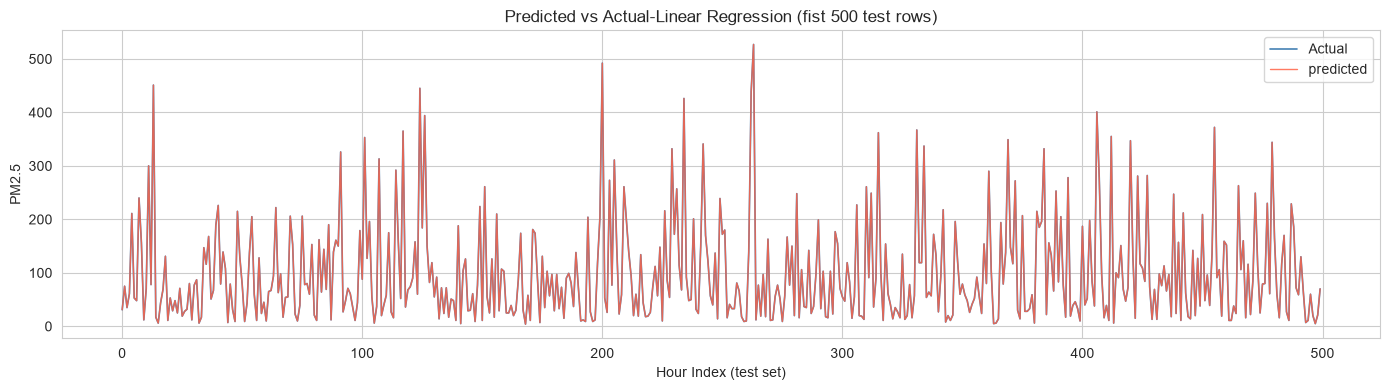

In [13]:
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression',y_test,y_pred))
models['Linear Regression'] = ('scaled',lr)
plot_prediction_model(y_test.values,y_pred,'Linear Regression')
plt.show()


 Ridge
RMSE  :21.1617
MAE   :12.2542
R2    :0.9454
MAPE  :0.2228


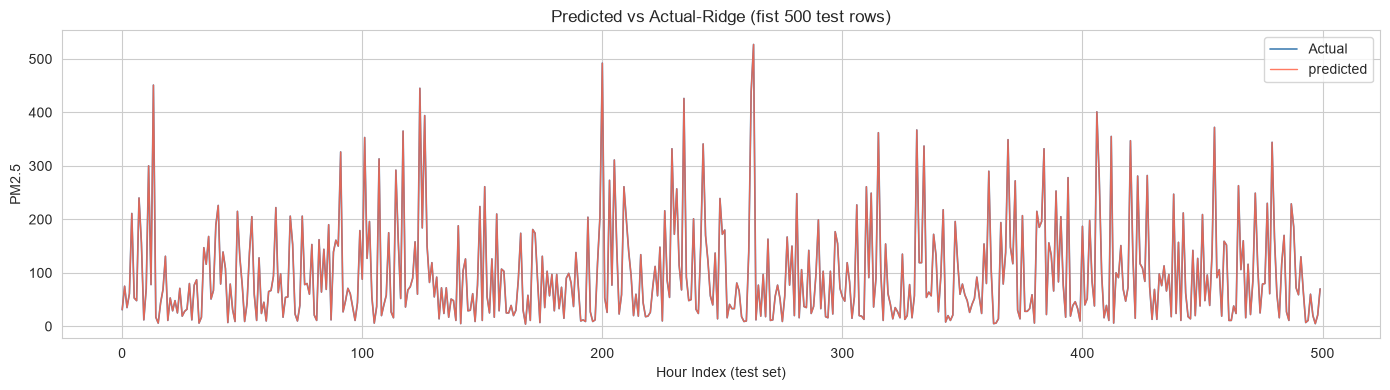

In [14]:
ridge  = Ridge(alpha=1.0,random_state=42)
ridge.fit(X_train_scaled,y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge',y_test,y_pred))
models['Ridge'] = ('scaled',ridge)
plot_prediction_model(y_test.values,y_pred,'Ridge')
plt.show()


 Lasso
RMSE  :21.1521
MAE   :12.1911
R2    :0.9454
MAPE  :0.2189


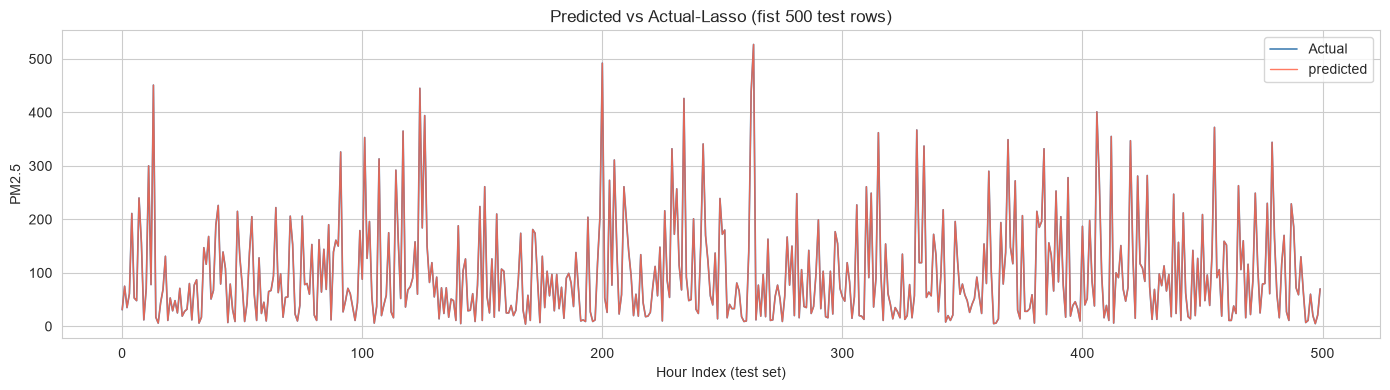

In [15]:
lasso  = Lasso(alpha=0.1,random_state=42,max_iter=10000)
lasso.fit(X_train_scaled,y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso',y_test,y_pred))
models['Lasso'] = ('scaled',lasso)
plot_prediction_model(y_test.values,y_pred,'Lasso')
plt.show()


 Decision Tree
RMSE  :28.5757
MAE   :13.9428
R2    :0.9004
MAPE  :0.2344


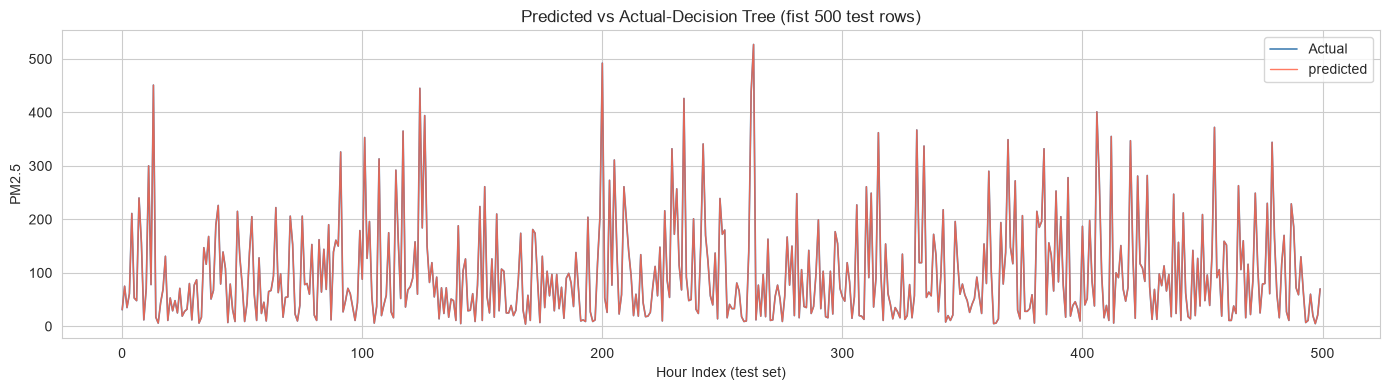

In [16]:
dt  = DecisionTreeRegressor(max_depth=10,random_state=42)
dt.fit(X_train_scaled,y_train)
y_pred = dt.predict(X_test_scaled)
results.append(evaluate_model('Decision Tree',y_test,y_pred))
models['Decision Tree'] = ('raw',dt)
plot_prediction_model(y_test.values,y_pred,'Decision Tree')
plt.show()


 Random Forest
RMSE  :21.4260
MAE   :12.4957
R2    :0.9440
MAPE  :0.2197


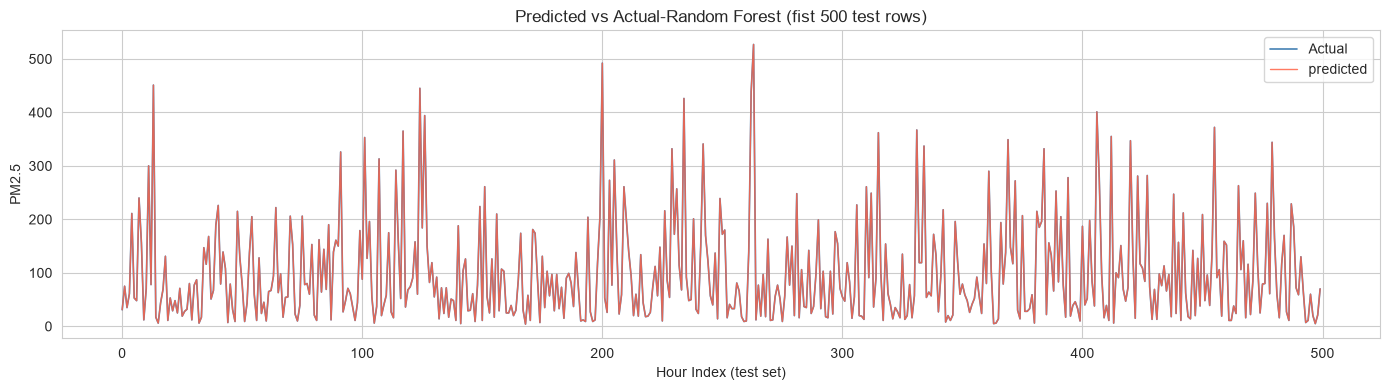

In [17]:
rf  = RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)
rf.fit(X_train_scaled,y_train)
y_pred = rf.predict(X_test_scaled)
results.append(evaluate_model('Random Forest',y_test,y_pred))
models['Random Forest'] = ('raw',rf)
plot_prediction_model(y_test.values,y_pred,'Random Forest')
plt.show()

3


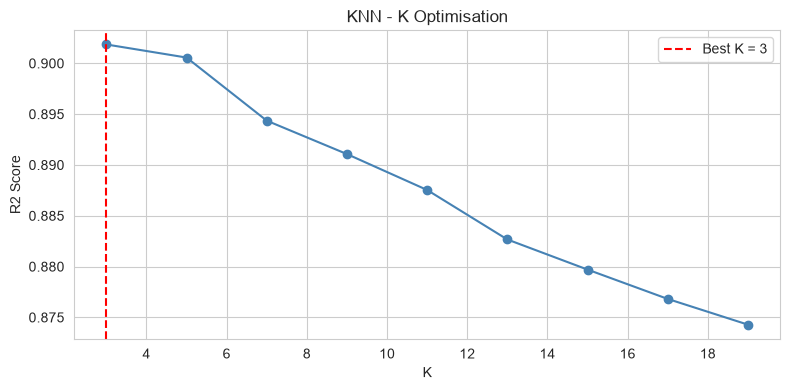


 KNN (k = 3)
RMSE  :28.3644
MAE   :17.3309
R2    :0.9019
MAPE  :0.3150


In [18]:
k_range = range(3,20,2)
k_scores = []

for k in k_range:
    knn_t = KNeighborsRegressor(n_neighbors=k,n_jobs=-1)
    knn_t.fit(X_train_scaled,y_train)
    k_scores.append(r2_score(y_test,knn_t.predict(X_test_scaled)))

best_k = list(k_range)[int(np.argmax(k_scores))]
print(best_k)

plt.figure(figsize=(8,4))
plt.plot(list(k_range),k_scores,marker='o',color='steelblue')
plt.axvline(best_k,color = 'red',linestyle='--',label = f'Best K = {best_k}')
plt.xlabel('K');plt.ylabel('R2 Score');plt.title('KNN - K Optimisation')
plt.legend();plt.tight_layout();plt.show()

knn = KNeighborsRegressor(n_neighbors=best_k,n_jobs=-1)
knn.fit(X_train_scaled,y_train)
y_pred = knn.predict(X_test_scaled)
knn_label = f'KNN (k = {best_k})'
results.append(evaluate_model(knn_label,y_test,y_pred))
models[knn_label] = ('scaled',knn)



 Gradient Boosting
RMSE  :20.4796
MAE   :12.0095
R2    :0.9488
MAPE  :0.2140


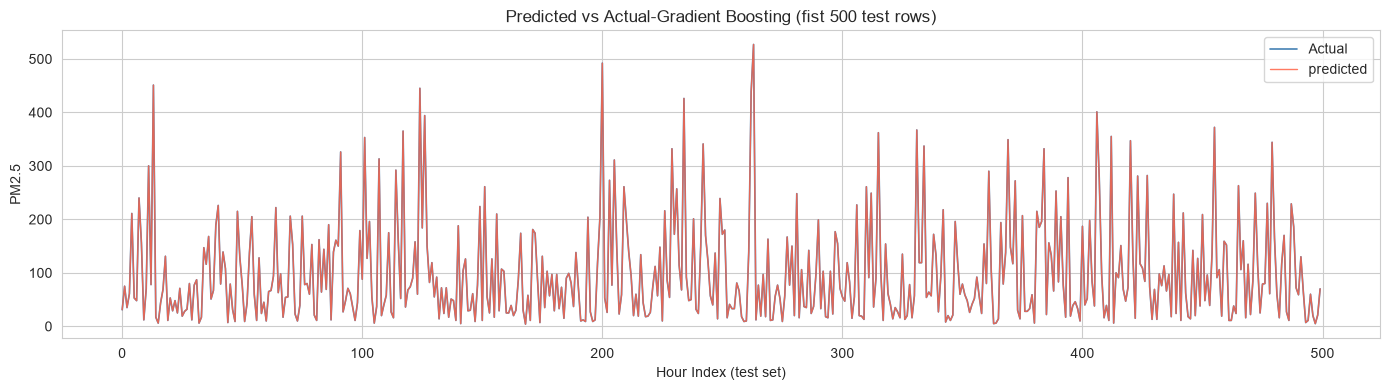

In [19]:
gb = GradientBoostingRegressor(n_estimators=200,learning_rate=0.1,max_depth=5,random_state=42)
gb.fit(X_train_scaled,y_train)
y_pred = gb.predict(X_test_scaled)
results.append(evaluate_model('Gradient Boosting',y_test,y_pred))
models['Gradient Boosting'] = ('raw',gb)
plot_prediction_model(y_test.values,y_pred,'Gradient Boosting')
plt.show()


**Model Comparision**

In [20]:
comparison = compare_models(results)
print(comparison.to_string(index=False))

            Model      RMSE       MAE       R2     MAPE
Gradient Boosting 20.479568 12.009521 0.948835 0.214031
            Lasso 21.152073 12.191053 0.945419 0.218877
            Ridge 21.161677 12.254232 0.945370 0.222834
Linear Regression 21.164328 12.252629 0.945356 0.222821
    Random Forest 21.425981 12.495750 0.943997 0.219713
      KNN (k = 3) 28.364411 17.330933 0.901852 0.315032
    Decision Tree 28.575665 13.942768 0.900385 0.234352


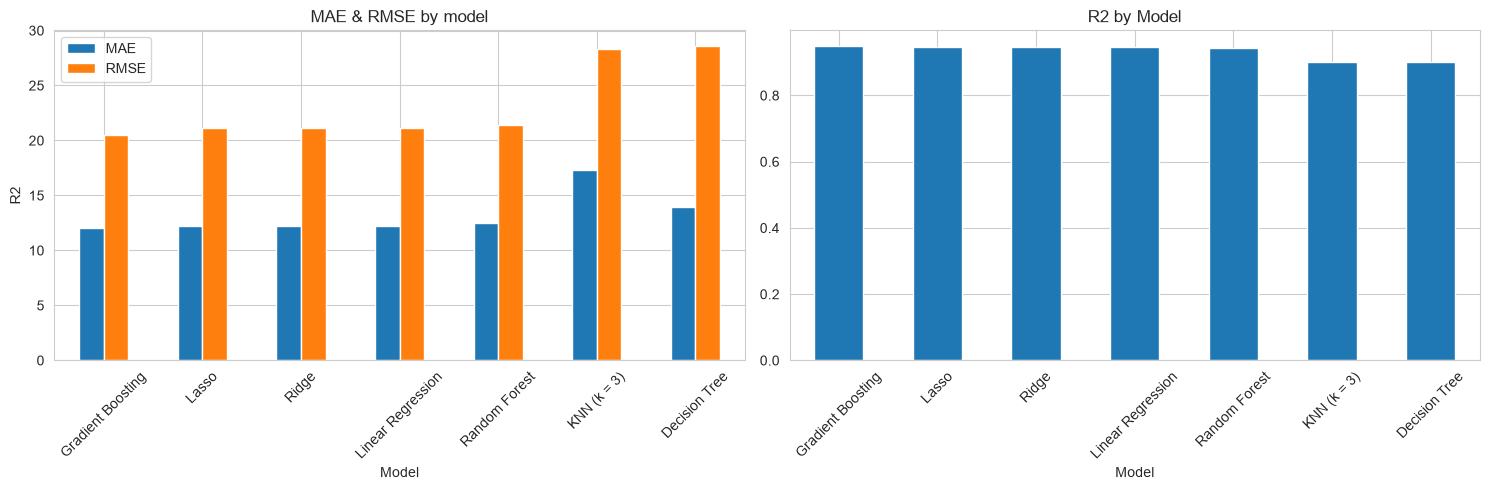

In [21]:
fig,axes = plt.subplots(1,2,figsize=(15,5))
comparison.set_index('Model')[['MAE','RMSE']].plot(kind='bar',ax = axes[0])
axes[0].set_title('MAE & RMSE by model');axes[0].set_ylabel('pm2.5')
axes[0].tick_params(axis='x',rotation=45)
comparison.set_index('Model')['R2'].plot(kind='bar',ax = axes[1])
axes[1].set_title('R2 by Model');axes[0].set_ylabel('R2')
axes[1].tick_params(axis='x',rotation=45)
plt.tight_layout();plt.show()

**Feauture Importance**

In [22]:
df.columns
feature_cols = ['year', 'month', 'day', 'hour','DEWP', 'TEMP', 'PRES',
       'Iws', 'Is', 'Ir','dayofweek', 'quarter', 'dayofyear',
       'is_weekend', 'lag_1', 'lag_24', 'roll_24', 'roll_168', 'wind_NW',
       'wind_SE', 'wind_cv']

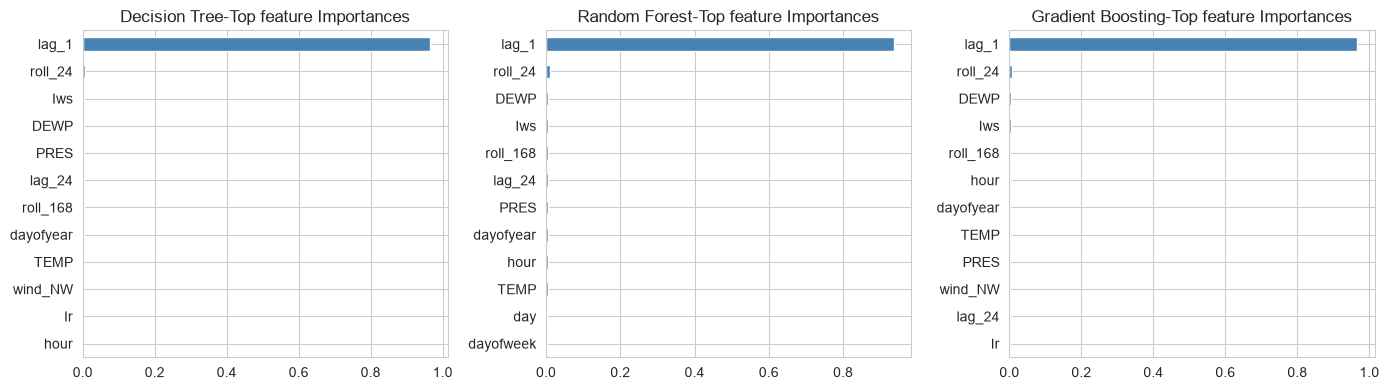

In [23]:
tree_model = [('Decision Tree',dt),('Random Forest',rf),('Gradient Boosting',gb)]
fig,axes = plt.subplots(1,3,figsize=(14,4))
for ax, (name,model) in zip(axes,tree_model):
   imp = pd.Series(model.feature_importances_, index = feature_cols).sort_values().tail(12)
   imp.plot(kind='barh',ax=ax,color='steelblue')
   ax.set_title(f'{name}-Top feature Importances')
plt.tight_layout();plt.show()

**Time-Series Cross-Validation**

In [24]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {}

cv_candidates = {
    'Linear Regression':('scaled',lr),
    'Ridge':('scaled',ridge),
    'Decision tree':('raw',dt),
    'Random Forest':('raw',rf),
    'Gradient Boosting':('raw',gb)
}

x_full_scaled = scaler.fit_transform(X)

for name,(kind,model) in cv_candidates.items():
    Xuse = x_full_scaled if kind == 'scaled' else X
    scores = cross_val_score(model,Xuse, y, cv=tscv, scoring='r2',n_jobs=-1)
    cv_scores[name] = scores
    print(f'{name:25s} mean R^2 = {scores.mean():.4f}) (+/- {scores.std():.4f}')


Linear Regression         mean R^2 = 0.9383) (+/- 0.0066
Ridge                     mean R^2 = 0.9383) (+/- 0.0067
Decision tree             mean R^2 = 0.8556) (+/- 0.0606
Random Forest             mean R^2 = 0.9225) (+/- 0.0091
Gradient Boosting         mean R^2 = 0.8953) (+/- 0.0557


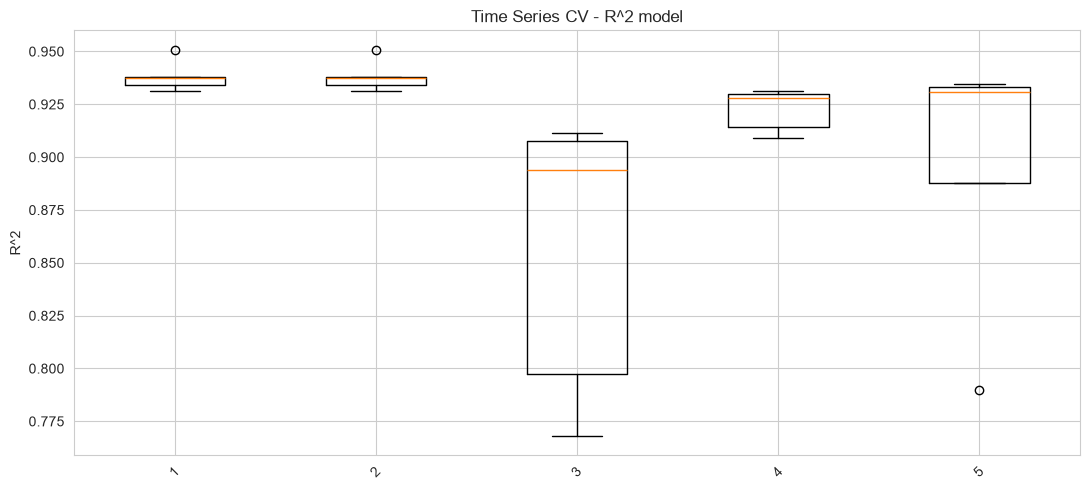

In [25]:
plt.figure(figsize = (11,5))
plt.boxplot([cv_scores[k] for k in cv_scores],label=list(cv_scores.keys()))
plt.title('Time Series CV - R^2 model');plt.ylabel('R^2')
plt.xticks(rotation = 45)
plt.tight_layout();plt.show()

**Hyperparameter Tuning**

In [26]:
best_model_name = comparison.iloc[0]['Model']
print(f'Best Model: {best_model_name}')

base_name = best_model_name.split(' (k=')[0] if 'KNN' in best_model_name else best_model_name
kind_best,best_obj = models[best_model_name]

if 'Random forest' in base_name:
    param_grid = {'n_estimators':[200,300],'max_depth':[None,20], 'min_sample_leaf':[1,2]}
    tuner_model = RandomForestRegressor(random_state=42,n_jobs=-1)
    use_scaled = False 
elif 'Gradient Boosting' in base_name:
    param_grid = {'n_estimators':[150,300],'max_depth':[4,5], 'learning_rate':[0.05,0.1]}
    tuner_model = GradientBoostingRegressor(random_state=42)
    use_scaled = False 
elif 'Decision Tree' in base_name:
    param_grid = {'max_depth':[8,10,15],'min_sample_leaf':[1,2,5]}
    tuner_model = DecisionTreeRegressor(random_state=42)
    use_scaled = False 
elif 'KNN' in base_name:
    param_grid = {'n_neighbors':[3,5,7,9]}
    tuner_model = KNeighborsRegressor(n_jobs=-1)
    use_scaled = False 
elif 'Ridge' in base_name:
    param_grid = {'alpha':[0.1,1.0,10.0,100.0]}
    tuner_model = ridge()
    use_scaled = False 
else :
    param_grid = {'alpha':[0.01,0.1,1.0]}
    tuner_model = Lasso(max_iter=10000)
    use_scaled = True 

Xtr_g = X_train_scaled if use_scaled else X_train
Xte_g = X_test_scaled if use_scaled else X_test

grid = GridSearchCV(tuner_model,param_grid,cv=TimeSeriesSplit(n_splits=3),scoring='r2',n_jobs=-1,verbose=0)
grid.fit(Xtr_g,y_train)
print(f'Best param',grid.best_params_)
print(f'Best CV R2',(round(grid.best_score_,4)))
best_tuned = grid.best_estimator_
print(best_tuned)
y_pred_tuned = best_tuned.predict(Xte_g)
tuned_label = f'{base_name} (Tuned)'
tuned_metrics = evaluate_model(tuned_label,y_test,y_pred_tuned)
results.append(tuned_metrics)



Best Model: Gradient Boosting
Best param {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150}
Best CV R2 0.9359
GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=150,
                          random_state=42)

 Gradient Boosting (Tuned)
RMSE  :20.7988
MAE   :11.8704
R2    :0.9472
MAPE  :0.2092


**Residual Analysis**

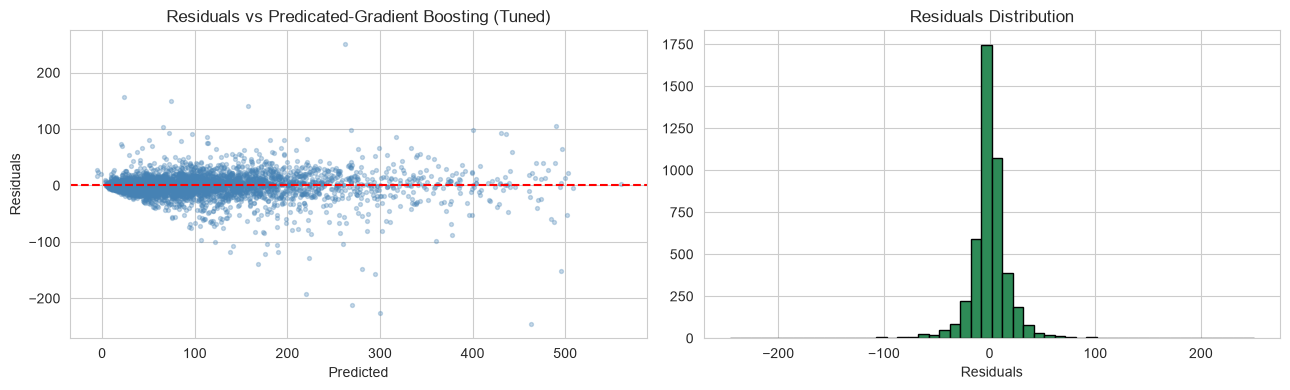

In [27]:
plot_residuals_model(y_test.values,y_pred,tuned_label)
plt.show()

**Prediction**

In [28]:
n_sample = 10
split_idx = int(len(df)*0.80)
sample_X = Xte_g[-n_sample:] if isinstance(Xte_g, np.ndarray) else Xte_g.iloc[-n_sample:]
sample_pred = best_tuned.predict(sample_X)
sample_actual = y_test.values[-n_sample:]

pred_df = pd.DataFrame({
    'Datetime': df['Datetime'].iloc[split_idx:].values[-n_sample:],
    'Actual':sample_actual.round(1),
    'predicted':sample_pred.round(1),
    'AbsError': np.abs(sample_actual-sample_pred).round(1)
})
pred_df

,Datetime,Actual,predicted,AbsError
0,2014-12-31 14:00:00,28.0,24.1,3.9
1,2014-12-31 15:00:00,24.0,26.4,2.4
2,2014-12-31 16:00:00,7.0,12.4,5.4
3,2014-12-31 17:00:00,107.0,129.8,22.8
4,2014-12-31 18:00:00,209.0,223.7,14.7
5,2014-12-31 19:00:00,31.0,47.1,16.1
6,2014-12-31 20:00:00,397.0,385.1,11.9
7,2014-12-31 21:00:00,7.0,10.9,3.9
8,2014-12-31 22:00:00,243.0,237.8,5.2
9,2014-12-31 23:00:00,182.0,177.0,5.0


**Final Summary**

*Model Comparison (all models, sorted by R²)*

In [ ]:
final = compare_models(results)
final_df = pd.DataFrame(final).round(2)
final_df


,Model,RMSE,MAE,R2,MAPE
0,Gradient Boosting,20.48,12.01,0.95,0.21
1,Gradient Boosting (Tuned),20.80,11.87,0.95,0.21
2,Lasso,21.15,12.19,0.95,0.22
3,Ridge,21.16,12.25,0.95,0.22
4,Linear Regression,21.16,12.25,0.95,0.22
5,Random Forest,21.43,12.50,0.94,0.22
6,KNN (k = 3),28.36,17.33,0.90,0.32
7,Decision Tree,28.58,13.94,0.90,0.23
